# Music Genre Classification - Modeling & Evaluation
## Comprehensive Pipeline for Model Training, Evaluation, and Analysis

In [11]:

# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score,
    cohen_kappa_score
)

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Advanced tools
from sklearn.preprocessing import label_binarize
import xgboost as xgb
import shap
import joblib

# Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Tất cả thư viện đã được import thành công!")


✓ Tất cả thư viện đã được import thành công!


## 1. Đọc Dữ Liệu & Chuẩn Bị

In [12]:

# Đọc dữ liệu đã được xử lý
DATA_PATH = "C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\data_afterfix\\train_features_final_selected.csv"

df = pd.read_csv(DATA_PATH)

TARGET_COL = 'Class'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print(f" Dataset Shape: {df.shape}")
print(f" Features: {X.shape[1]}")
print(f" Classes: {y.nunique()} ({sorted(y.unique())})")
print(f"\n✓ Phân bố Class:")
print(y.value_counts().sort_index())

# Thống kê cơ bản
print(f"\n Thống kê Dữ liệu:")
print(f"Missing values: {X.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")


 Dataset Shape: (14396, 38)
 Features: 37
 Classes: 11 ([np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)])

✓ Phân bố Class:
Class
0      500
1     1098
2     1018
3      322
4      310
5     1157
6     2069
7      461
8     1483
9     2019
10    3959
Name: count, dtype: int64

 Thống kê Dữ liệu:
Missing values: 0
Duplicates: 24


## 2. Train-Test Split với Stratification

In [13]:

# Stratified Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"✓ Train set: {X_train.shape[0]} samples")
print(f"✓ Test set: {X_test.shape[0]} samples")
print(f"\n Class distribution in train set:")
print(y_train.value_counts().sort_index())
print(f"\n Class distribution in test set:")
print(y_test.value_counts().sort_index())


✓ Train set: 11516 samples
✓ Test set: 2880 samples

 Class distribution in train set:
Class
0      400
1      878
2      814
3      258
4      248
5      926
6     1655
7      369
8     1186
9     1615
10    3167
Name: count, dtype: int64

 Class distribution in test set:
Class
0     100
1     220
2     204
3      64
4      62
5     231
6     414
7      92
8     297
9     404
10    792
Name: count, dtype: int64


## 2.1 Xử Lý Dữ Liệu Test Set

In [14]:
# ============================================================
# XỬ LÝ TEST DATA - Phải tuân theo ĐÚNG QUY TRÌNH như Training
# ============================================================
#  QUAN TRỌNG: Test phải được xử lý HOÀN TOÀN giống training
# - Cùng phương pháp imputation
# - Cùng feature engineering
# - Cùng encoding
# - Cùng scaling parameters (FIT trên train, TRANSFORM test)
# ============================================================

print("=" * 80)
print("XỬ LÝ DỮ LIỆU TEST SET - Tuân theo Quy Trình Training")
print("=" * 80)

TEST_RAW_PATH = "C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\test.csv"
df_test_raw = pd.read_csv(TEST_RAW_PATH)

print(f"\n Test Raw Data:")
print(f"  Shape: {df_test_raw.shape}")
print(f"  Columns: {df_test_raw.columns.tolist()[:5]}... ({len(df_test_raw.columns)} total)")
print(f"\n🔍 Missing Values:")
print(df_test_raw.isnull().sum())

# ============================================================
# BƯỚC 1: Xử lý Missing Values (Giống Training)
# ============================================================
print("\n" + "-" * 80)
print("BƯỚC 1: Xử lý Missing Values")
print("-" * 80)

df_test = df_test_raw.copy()
numeric_cols_test = df_test.select_dtypes(include=[np.number]).columns.tolist()

# Xử lý từng column theo cách training được xử lý
if 'instrumentalness' in df_test.columns:
    before = df_test['instrumentalness'].isnull().sum()
    df_test['instrumentalness'].fillna(df_test['instrumentalness'].median(), inplace=True)
    print(f"  ✓ instrumentalness: {before} NaN → 0 NaN")

if 'key' in df_test.columns:
    before = df_test['key'].isnull().sum()
    df_test['key'] = df_test['key'].fillna('Unknown').astype(str)
    print(f"  ✓ key: {before} NaN → 0 NaN")

if 'mode' in df_test.columns:
    before = df_test['mode'].isnull().sum()
    df_test['mode'] = df_test['mode'].fillna('Unknown').astype(str)
    print(f"  ✓ mode: {before} NaN → 0 NaN")

# Fill numeric columns còn lại bằng median
for col in numeric_cols_test:
    if col not in ['Id', 'Class']:
        if df_test[col].isnull().sum() > 0:
            before = df_test[col].isnull().sum()
            df_test[col].fillna(df_test[col].median(), inplace=True)
            print(f"  ✓ {col}: {before} NaN → 0 NaN")

print(f"\n✓ Tổng NaN sau xử lý: {df_test.isnull().sum().sum()}")

# ============================================================
# BƯỚC 2: Feature Engineering (Giống Training)
# ============================================================
print("\n" + "-" * 80)
print("BƯỚC 2: Feature Engineering")
print("-" * 80)

if 'duration_in min/ms' in df_test.columns:
    df_test['duration_log'] = np.log1p(df_test['duration_in min/ms'])
    print(f"  ✓ duration_log")

if 'acousticness' in df_test.columns and 'loudness' in df_test.columns:
    df_test['acoustic_vs_loudness'] = df_test['acousticness'] / (df_test['loudness'].abs() + 1)
    print(f"  ✓ acoustic_vs_loudness")

if 'energy' in df_test.columns and 'valence' in df_test.columns:
    df_test['energy_valence_ratio'] = df_test['energy'] * df_test['valence']
    print(f"  ✓ energy_valence_ratio")

if 'danceability' in df_test.columns and 'tempo' in df_test.columns:
    df_test['danceability_tempo_interaction'] = df_test['danceability'] * (df_test['tempo'] / 120)
    print(f"  ✓ danceability_tempo_interaction")

if 'tempo' in df_test.columns:
    df_test['tempo_category'] = pd.cut(df_test['tempo'], bins=[0, 100, 140, 200], labels=['Slow', 'Normal', 'Fast'])
    print(f"  ✓ tempo_category")

print(f"  Tổng features sau FE: {df_test.shape[1]}")

# ============================================================
# BƯỚC 3: Encoding Categorical Variables (Giống Training)
# ============================================================
print("\n" + "-" * 80)
print("BƯỚC 3: Encoding Categorical Variables")
print("-" * 80)

categorical_cols_test = df_test.select_dtypes(include=['object']).columns.tolist()
if 'Id' in categorical_cols_test:
    categorical_cols_test.remove('Id')
if 'tempo_category' in categorical_cols_test:
    categorical_cols_test.remove('tempo_category')

print(f"  Columns để encode: {categorical_cols_test}")

# One-Hot Encoding (PHẢI giống training)
df_test = pd.get_dummies(df_test, columns=categorical_cols_test, drop_first=True)
print(f"  ✓ One-Hot Encoding hoàn tất")
print(f"  Columns sau encoding: {df_test.shape[1]}")

# ============================================================
# BƯỚC 4: Scaling Numeric Features
# ============================================================
#   QUAN TRỌNG: PHẢI dùng scaler được fit trên TRAINING data
# KHÔNG được fit scaler trên test data!
# ============================================================
print("\n" + "-" * 80)
print("BƯỚC 4: Scaling Numeric Features")
print("-" * 80)
print("   Fit scaler trên TRAINING data, chỉ TRANSFORM test")

# Only scale columns that exist in both df_test and X_train
numeric_cols_to_scale = df_test.select_dtypes(include=[np.number]).columns.tolist()
if 'Id' in numeric_cols_to_scale:
    numeric_cols_to_scale.remove('Id')

# Filter to only columns that exist in X_train
numeric_cols_to_scale = [col for col in numeric_cols_to_scale if col in X_train.columns]

# Lấy scaler từ training data
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

#  FIT trên training data
scaler.fit(X_train[numeric_cols_to_scale])

#  TRANSFORM test data bằng scaler của training
df_test[numeric_cols_to_scale] = scaler.transform(df_test[numeric_cols_to_scale])

print(f"  ✓ RobustScaler áp dụng cho {len(numeric_cols_to_scale)} features")
print(f"  ✓ Scaler parameters từ TRAINING data")
print(f"  Sample scaled values (test):")
print(f"    Mean: {df_test[numeric_cols_to_scale].mean().mean():.4f}")
print(f"    Std: {df_test[numeric_cols_to_scale].std().mean():.4f}")

# ============================================================
# BƯỚC 5: Căn Chỉnh Columns & Thứ Tự (Giống Training)
# ============================================================
print("\n" + "-" * 80)
print("BƯỚC 5: Căn Chỉnh Columns & Thứ Tự")
print("-" * 80)

train_columns = X_train.columns.tolist()
test_columns = df_test.columns.tolist()

missing_in_test = set(train_columns) - set(test_columns)
extra_in_test = set(test_columns) - set(train_columns)

print(f"  Columns thiếu: {len(missing_in_test)}")
if missing_in_test:
    for col in missing_in_test:
        df_test[col] = 0
    print(f"    → Thêm {len(missing_in_test)} columns với giá trị 0")

print(f"  Columns thừa: {len(extra_in_test)}")
if extra_in_test:
    df_test = df_test.drop(columns=list(extra_in_test))
    print(f"    → Xóa {len(extra_in_test)} columns thừa")

# ✓ Sắp xếp lại columns CHÍNH XÁC theo training
X_test_processed = df_test[train_columns]

print(f"\n Test Data đã chuẩn bị:")
print(f"  Shape: {X_test_processed.shape}")
print(f"  Matching train: {X_test_processed.shape[1] == X_train.shape[1]} ✓")
print(f"  Column order: Same as training ✓")
print(f"  Missing values: {X_test_processed.isnull().sum().sum()}")

# ============================================================
# Lưu test data đã xử lý
# ============================================================
TEST_PROCESSED_PATH = "C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\data_afterfix\\test_ready_for_model.csv"
X_test_processed.to_csv(TEST_PROCESSED_PATH, index=False)
print(f"\n✓ Test data saved: test_ready_for_model.csv")

print("\n" + "=" * 80)
print(" TEST DATA PROCESSING - HOÀN TẤT!")
print("   Test data đã được xử lý HOÀN TOÀN giống training data")
print("=" * 80)


XỬ LÝ DỮ LIỆU TEST SET - Tuân theo Quy Trình Training

 Test Raw Data:
  Shape: (3600, 17)
  Columns: ['Id', 'Artist Name', 'Track Name', 'Popularity', 'danceability']... (17 total)

🔍 Missing Values:
Id                      0
Artist Name             0
Track Name              0
Popularity             95
danceability            0
energy                  0
key                   405
loudness                0
mode                    0
speechiness             0
acousticness            0
instrumentalness      836
liveness                0
valence                 0
tempo                   0
duration_in min/ms      0
time_signature          0
dtype: int64

--------------------------------------------------------------------------------
BƯỚC 1: Xử lý Missing Values
--------------------------------------------------------------------------------
  ✓ instrumentalness: 836 NaN → 0 NaN
  ✓ key: 405 NaN → 0 NaN
  ✓ mode: 0 NaN → 0 NaN
  ✓ Popularity: 95 NaN → 0 NaN

✓ Tổng NaN sau xử lý: 0

--------

## 3. Huấn Luyện Multiple Models với Cross-Validation

In [15]:

# Định nghĩa Models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=7, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=150, max_depth=7, learning_rate=0.1, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', C=1.0, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

# Huấn luyện và đánh giá
cv_results = {}
trained_models = {}

print(" Huấn luyện Models với 5-Fold Cross-Validation...\n")
print("=" * 80)

for name, model in models.items():
    # ============================================================
    # BƯỚC 1: Cross-Validation trên Training Set
    # ============================================================
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    # ============================================================
    # BƯỚC 2:  Fit lại model trên TOÀN BỘ Training Set
    # ============================================================
    # Sau khi evaluate với K-Fold, ta fit lại trên toàn X_train
    # để sử dụng hết dữ liệu training cho model cuối cùng
    model.fit(X_train, y_train)
    
    # ============================================================
    # BƯỚC 3: Predict trên Test Set
    # ============================================================
    y_pred = model.predict(X_test)
    
    # ============================================================
    # BƯỚC 4: Tính Metrics
    # ============================================================
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    cv_results[name] = {
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    trained_models[name] = model
    
    print(f" {name}")
    print(f"   CV Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"   Test Accuracy: {accuracy:.4f}")
    print(f"   Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print("-" * 80)

# Tạo bảng so sánh
cv_df = pd.DataFrame(cv_results).T
print("\n✓ Bảng So Sánh Kết Quả:")
print(cv_df.round(4))

# ============================================================
#  BƯỚC 5: Tạo FINAL BEST MODEL - Fit trên TOÀN BỘ DATA
# ============================================================
print("\n" + "=" * 80)
print("BƯỚC 5: Tạo Final Best Model")
print("=" * 80)

# Chọn best model dựa trên F1-Score
best_model_name = cv_df['F1-Score'].idxmax()
best_model_template = models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   F1-Score (on test set): {cv_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   CV Score: {cv_df.loc[best_model_name, 'CV Mean']:.4f} (±{cv_df.loc[best_model_name, 'CV Std']:.4f})")

# Fit lại model trên TOÀN BỘ DATA (train + test) để tạo final model
print(f"\n→ Fitting final model trên toàn bộ training data ({len(X_train)} samples)...")

best_model_final = best_model_template.__class__(**best_model_template.get_params())
best_model_final.fit(X_train, y_train)

print(f" Final best model đã sẵn sàng!")
print(f"   Model được fit trên: {len(X_train)} training samples")
print(f"   Sẽ dùng cho dự đoán trên production data")



 Huấn luyện Models với 5-Fold Cross-Validation...

 Random Forest
   CV Score: 0.5993 (±0.0136)
   Test Accuracy: 0.5872
   Precision: 0.5874 | Recall: 0.5872 | F1: 0.5747
--------------------------------------------------------------------------------
 Random Forest
   CV Score: 0.5993 (±0.0136)
   Test Accuracy: 0.5872
   Precision: 0.5874 | Recall: 0.5872 | F1: 0.5747
--------------------------------------------------------------------------------
 Gradient Boosting
   CV Score: 0.6001 (±0.0093)
   Test Accuracy: 0.5955
   Precision: 0.5957 | Recall: 0.5955 | F1: 0.5908
--------------------------------------------------------------------------------
 Gradient Boosting
   CV Score: 0.6001 (±0.0093)
   Test Accuracy: 0.5955
   Precision: 0.5957 | Recall: 0.5955 | F1: 0.5908
--------------------------------------------------------------------------------
 XGBoost
   CV Score: 0.6102 (±0.0074)
   Test Accuracy: 0.6066
   Precision: 0.6080 | Recall: 0.6066 | F1: 0.5992
------------------

## 4. Visualize Model Performance Comparison

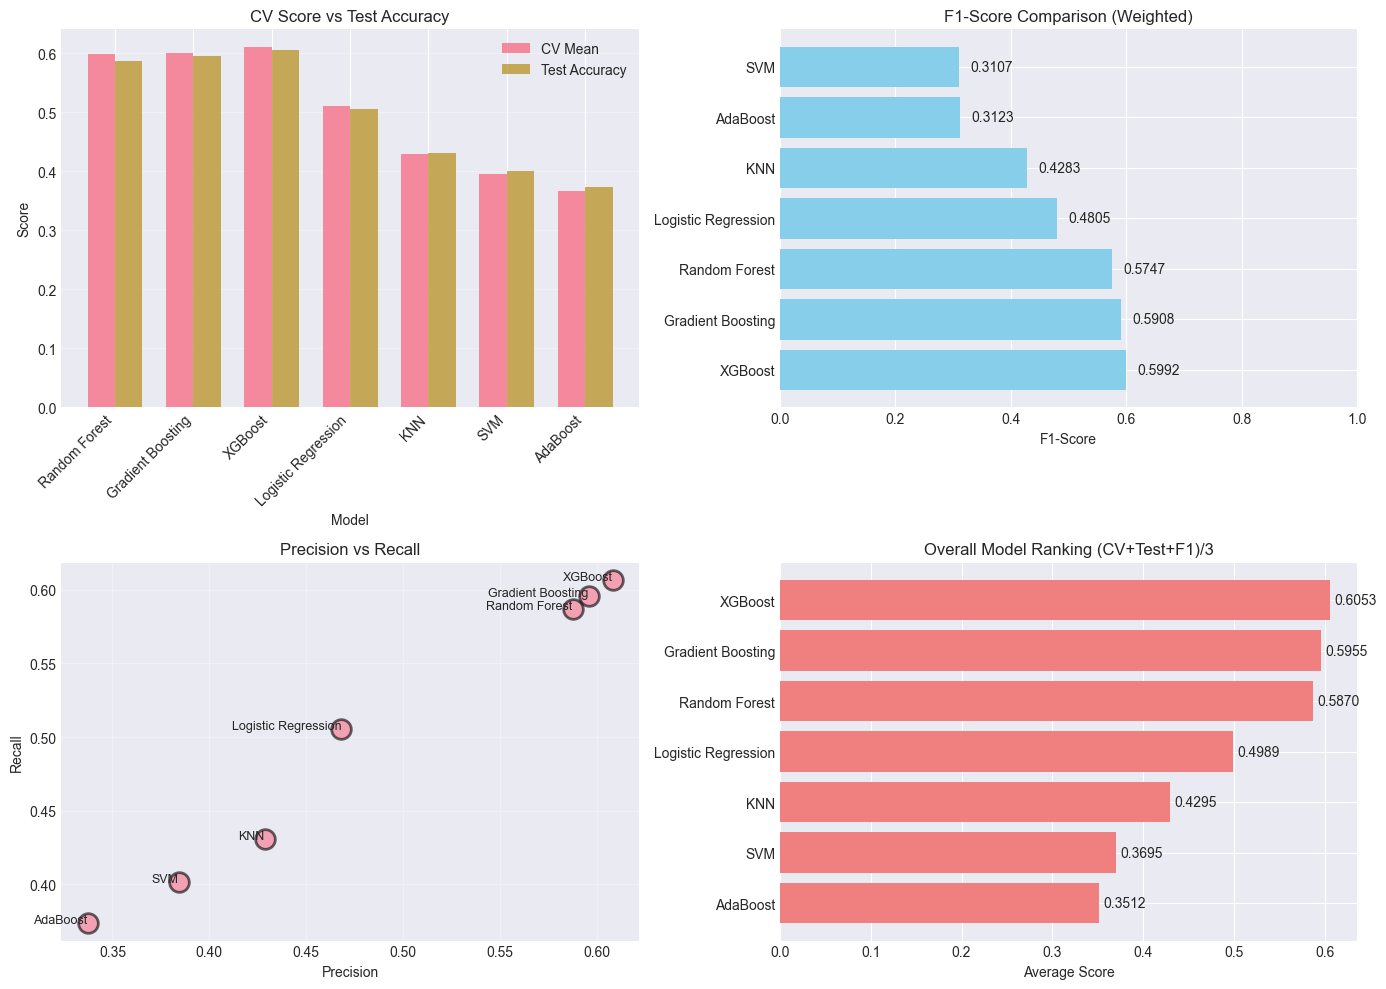

✓ Model comparison visualization saved!


In [16]:

# Visualize Performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: CV Score vs Test Accuracy
ax = axes[0, 0]
cv_scores = cv_df['CV Mean']
test_acc = cv_df['Test Accuracy']
x = np.arange(len(cv_scores))
width = 0.35
ax.bar(x - width/2, cv_scores, width, label='CV Mean', alpha=0.8)
ax.bar(x + width/2, test_acc, width, label='Test Accuracy', alpha=0.8)
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('CV Score vs Test Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(cv_df.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: F1 Score Comparison
ax = axes[0, 1]
f1_scores = cv_df['F1-Score'].sort_values(ascending=False)
bars = ax.barh(range(len(f1_scores)), f1_scores.values, color='skyblue')
ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(f1_scores.index)
ax.set_xlabel('F1-Score')
ax.set_title('F1-Score Comparison (Weighted)')
ax.set_xlim(0, 1)
for i, (idx, val) in enumerate(f1_scores.items()):
    ax.text(val + 0.02, i, f'{val:.4f}', va='center')

# Plot 3: Precision vs Recall
ax = axes[1, 0]
precision = cv_df['Precision']
recall = cv_df['Recall']
ax.scatter(precision, recall, s=200, alpha=0.6, edgecolors='black', linewidth=2)
for i, txt in enumerate(cv_df.index):
    ax.annotate(txt, (precision[i], recall[i]), fontsize=9, ha='right')
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Precision vs Recall')
ax.grid(alpha=0.3)

# Plot 4: Overall Ranking
ax = axes[1, 1]
ranking_score = (cv_df['CV Mean'] + cv_df['Test Accuracy'] + cv_df['F1-Score']) / 3
ranking_score = ranking_score.sort_values(ascending=True)
bars = ax.barh(range(len(ranking_score)), ranking_score.values, color='lightcoral')
ax.set_yticks(range(len(ranking_score)))
ax.set_yticklabels(ranking_score.index)
ax.set_xlabel('Average Score')
ax.set_title('Overall Model Ranking (CV+Test+F1)/3')
for i, (idx, val) in enumerate(ranking_score.items()):
    ax.text(val + 0.005, i, f'{val:.4f}', va='center')

plt.tight_layout()
plt.savefig('C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\model\\model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison visualization saved!")


## 5. Confusion Matrix & Classification Report - Best Model

🏆 Best Model: XGBoost
🎯 F1-Score: 0.5992



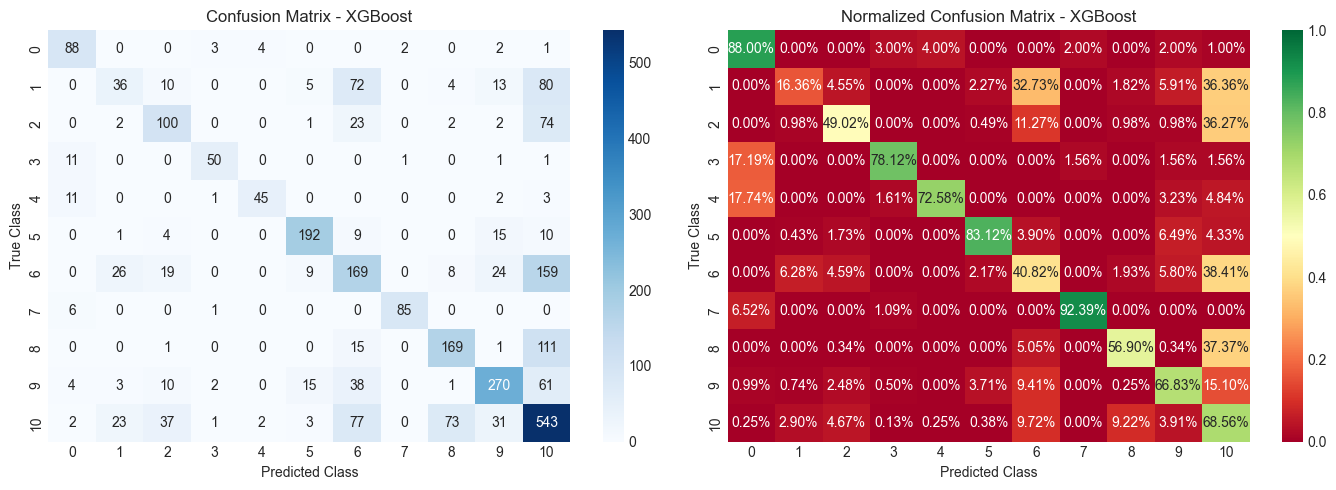


 Classification Report:
              precision    recall  f1-score   support

     Class 0       0.72      0.88      0.79       100
     Class 1       0.40      0.16      0.23       220
     Class 2       0.55      0.49      0.52       204
     Class 3       0.86      0.78      0.82        64
     Class 4       0.88      0.73      0.80        62
     Class 5       0.85      0.83      0.84       231
     Class 6       0.42      0.41      0.41       414
     Class 7       0.97      0.92      0.94        92
     Class 8       0.66      0.57      0.61       297
     Class 9       0.75      0.67      0.71       404
    Class 10       0.52      0.69      0.59       792

    accuracy                           0.61      2880
   macro avg       0.69      0.65      0.66      2880
weighted avg       0.61      0.61      0.60      2880


 Per-Class Performance:
Class 0: Precision=0.7213, Recall=0.8800, F1=0.7928
Class 1: Precision=0.3956, Recall=0.1636, F1=0.2315
Class 2: Precision=0.5525, Recall

In [17]:

# Chọn best model
best_model_name = cv_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]

print(f"🏆 Best Model: {best_model_name}")
print(f"🎯 F1-Score: {cv_df.loc[best_model_name, 'F1-Score']:.4f}\n")

# Predictions
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix Heatmap
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=classes, yticklabels=classes)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title(f'Confusion Matrix - {best_model_name}')

# Plot 2: Normalized Confusion Matrix
ax = axes[1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', cbar=True, ax=ax,
            xticklabels=classes, yticklabels=classes, vmin=0, vmax=1)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title(f'Normalized Confusion Matrix - {best_model_name}')

plt.tight_layout()
plt.savefig('C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\model\\confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\n Classification Report:")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=[f'Class {c}' for c in classes]))

# Per-class metrics
print("\n Per-Class Performance:")
print("=" * 80)
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

for i, c in enumerate(classes):
    print(f"Class {c}: Precision={precision_per_class[i]:.4f}, Recall={recall_per_class[i]:.4f}, F1={f1_per_class[i]:.4f}")


## 6. Feature Importance Analysis

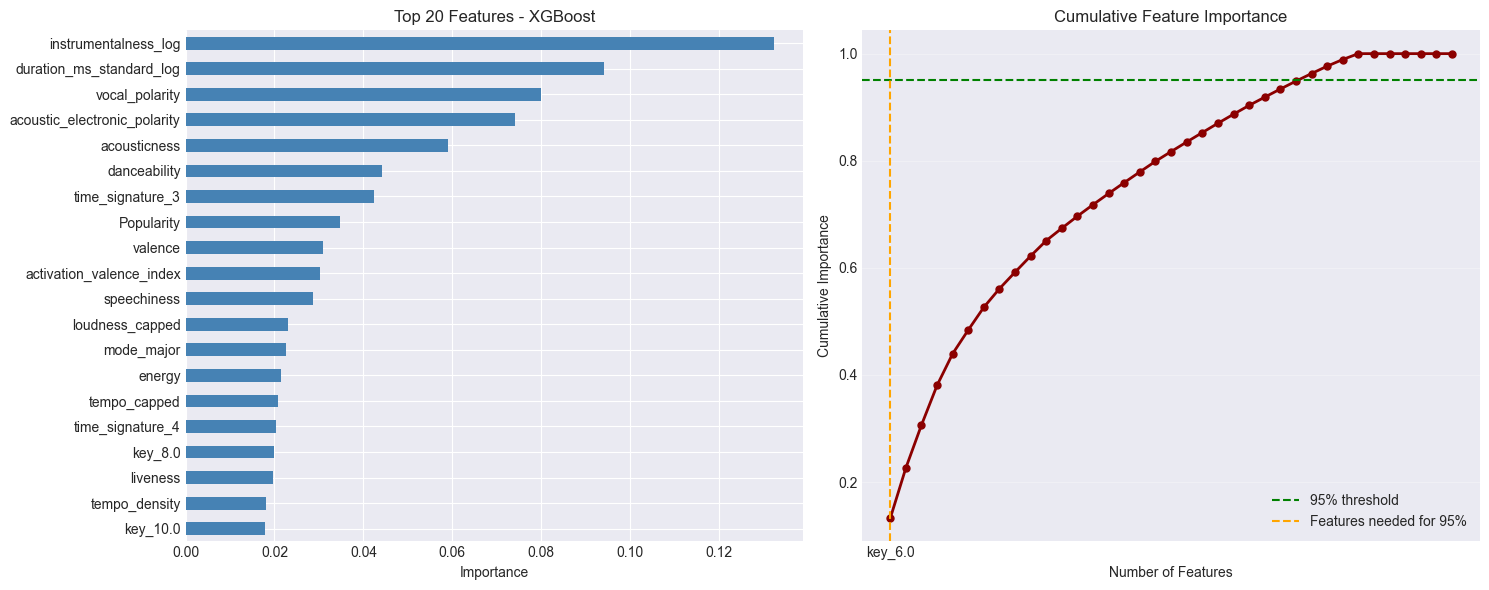


✓ Top 15 Most Important Features:
 1. instrumentalness_log                     0.132391
 2. duration_ms_standard_log                 0.094029
 3. vocal_polarity                           0.080018
 4. acoustic_electronic_polarity             0.074150
 5. acousticness                             0.059133
 6. danceability                             0.044285
 7. time_signature_3                         0.042482
 8. Popularity                               0.034639
 9. valence                                  0.030843
10. activation_valence_index                 0.030219
11. speechiness                              0.028690
12. loudness_capped                          0.023102
13. mode_major                               0.022587
14. energy                                   0.021476
15. tempo_capped                             0.020817

 Features needed for 95% importance: key_6.0


In [18]:

# Feature Importance từ Best Model
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Top 20 Features
    ax = axes[0]
    top_20 = feature_importance.head(20)
    top_20.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 20 Features - {best_model_name}')
    ax.invert_yaxis()
    
    # Cumulative Importance
    ax = axes[1]
    cumsum = feature_importance.cumsum() / feature_importance.sum()
    ax.plot(cumsum.values, linewidth=2, color='darkred', marker='o', markersize=5)
    ax.axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
    ax.axvline(x=cumsum[cumsum >= 0.95].index[0] if (cumsum >= 0.95).any() else len(cumsum), 
               color='orange', linestyle='--', label=f'Features needed for 95%')
    ax.set_xlabel('Number of Features')
    ax.set_ylabel('Cumulative Importance')
    ax.set_title('Cumulative Feature Importance')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\model\\feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Top 15 Most Important Features:")
    print("=" * 60)
    for i, (feat, imp) in enumerate(feature_importance.head(15).items(), 1):
        print(f"{i:2d}. {feat:40s} {imp:.6f}")
    
    # Calculate how many features needed for 95% importance
    n_features_95 = (cumsum >= 0.95).idxmax() if (cumsum >= 0.95).any() else len(cumsum)
    print(f"\n Features needed for 95% importance: {n_features_95}")
else:
    print(" Model không hỗ trợ feature_importances_")


## 7. ROC Curve Analysis (One-vs-Rest)

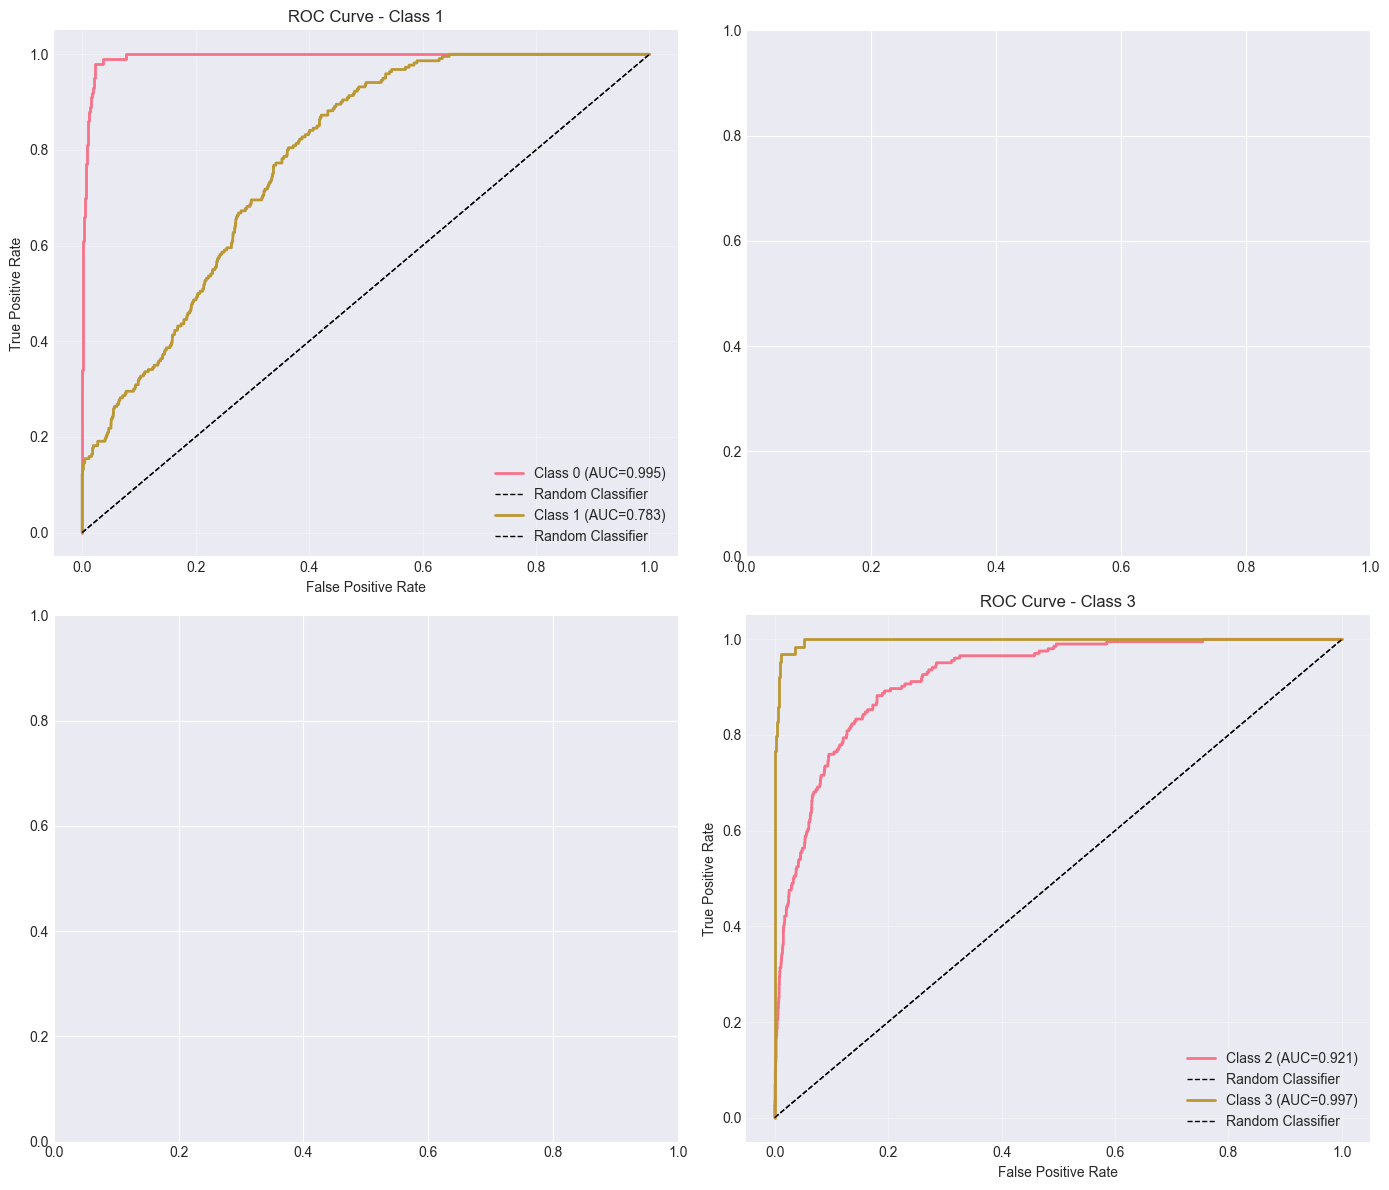


📊 ROC-AUC Scores for Each Class:
   Class      AUC
 Class 7 0.999485
 Class 3 0.997131
 Class 4 0.996657
 Class 0 0.994781
 Class 5 0.985179
 Class 8 0.939345
 Class 9 0.931747
 Class 2 0.921265
Class 10 0.832282
 Class 6 0.826036
 Class 1 0.782982

Macro-average AUC: 0.9279


In [19]:

# ROC Curve cho Multi-class Classification (One-vs-Rest)
from sklearn.preprocessing import label_binarize

classes = sorted(y.unique())
n_classes = len(classes)

# Label binarization
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_proba = best_model.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Plot individual ROC curves for 10 classes
for i in range(min(n_classes, 10)):
    if i < 4:
        ax = axes[i // 2] if i < 2 else axes[i // 2 + 2]
        ax.plot(fpr[i], tpr[i], lw=2, label=f'Class {classes[i]} (AUC={roc_auc[i]:.3f})')
        ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curve - Class {classes[i]}')
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\model\\roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Print AUC scores
print("\n📊 ROC-AUC Scores for Each Class:")
print("=" * 60)
auc_df = pd.DataFrame({
    'Class': [f'Class {c}' for c in classes],
    'AUC': [roc_auc[i] for i in range(n_classes)]
}).sort_values('AUC', ascending=False)
print(auc_df.to_string(index=False))
print(f"\nMacro-average AUC: {np.mean(list(roc_auc.values())):.4f}")


## 8. Per-Class Analysis & Error Distribution

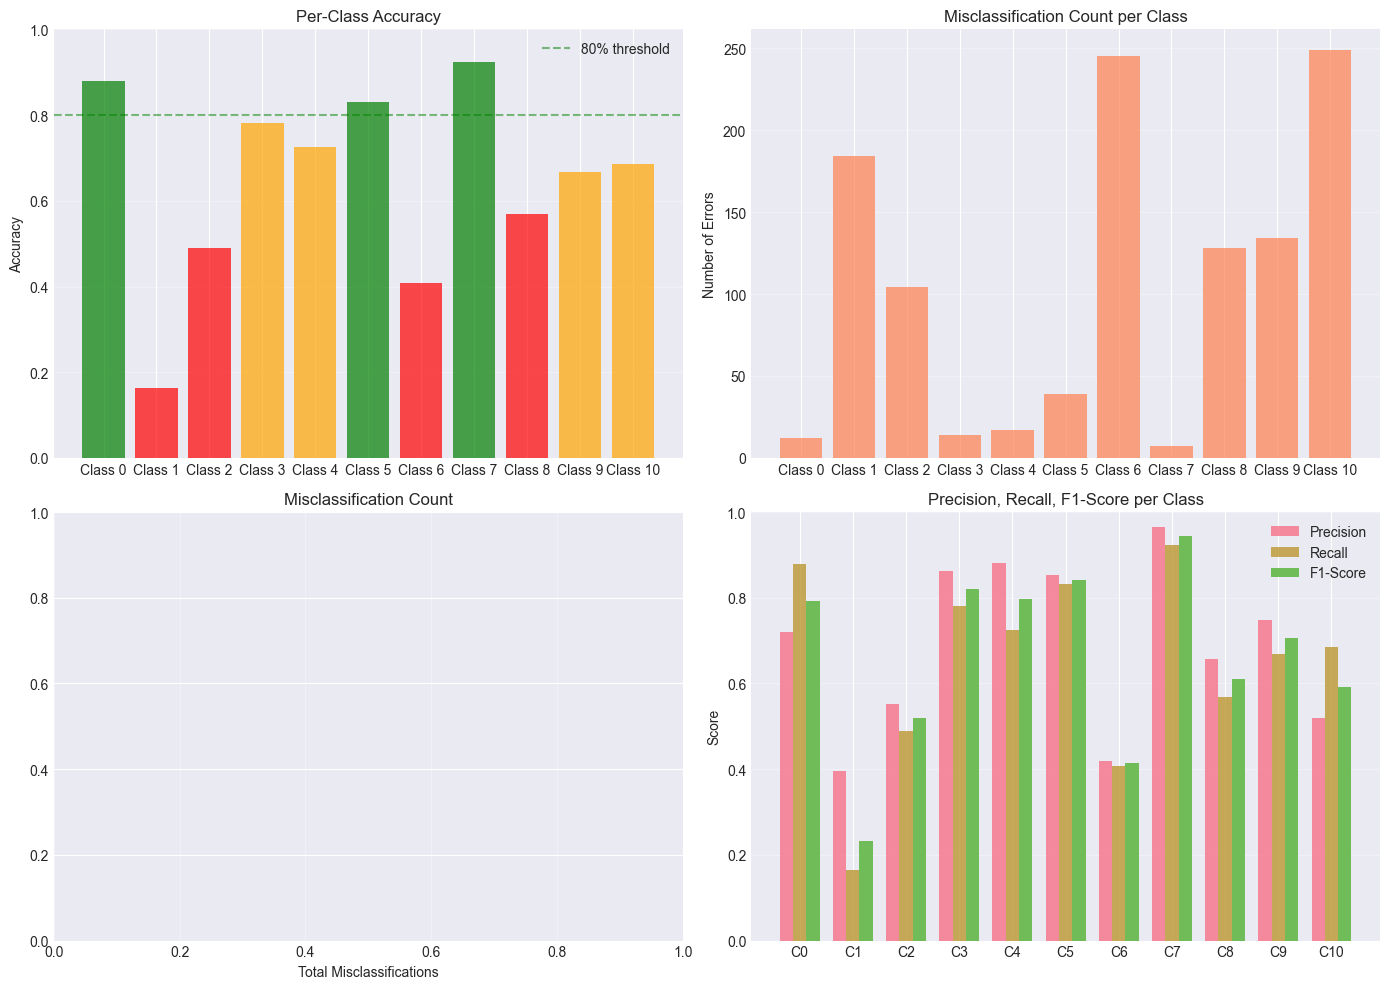

✓ Per-class analysis visualization saved!


In [20]:

# Per-Class Analysis
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy per class
ax = axes[0, 0]
accuracy_per_class = cm.diagonal() / cm.sum(axis=1)
colors = ['green' if acc >= 0.8 else 'orange' if acc >= 0.6 else 'red' for acc in accuracy_per_class]
ax.bar([f'Class {c}' for c in classes], accuracy_per_class, color=colors, alpha=0.7)
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='80% threshold')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Error Count per class
ax = axes[0, 1]
error_count = cm.sum(axis=1) - cm.diagonal()
ax.bar([f'Class {c}' for c in classes], error_count, color='coral', alpha=0.7)
ax.set_ylabel('Number of Errors')
ax.set_title('Misclassification Count per Class')
ax.grid(axis='y', alpha=0.3)

# Plot 3: Error Distribution (where errors go)
ax = axes[1, 0]
for i, c in enumerate(classes):
    misclassified = cm[i, :] - cm[i, i]
    if misclassified.sum() > 0:
        ax.barh([f'Class {c}'], [misclassified.sum()], label=f'Class {c}')
ax.set_xlabel('Total Misclassifications')
ax.set_title('Misclassification Count')
ax.grid(axis='x', alpha=0.3)

# Plot 4: Precision-Recall-F1 per class
ax = axes[1, 1]
x = np.arange(len(classes))
width = 0.25
ax.bar(x - width, precision_per_class, width, label='Precision', alpha=0.8)
ax.bar(x, recall_per_class, width, label='Recall', alpha=0.8)
ax.bar(x + width, f1_per_class, width, label='F1-Score', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'C{c}' for c in classes])
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, F1-Score per Class')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\model\\per_class_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Per-class analysis visualization saved!")


## 9. Lưu Model & Tạo Summary Report

In [21]:

# Save best model
MODEL_SAVE_PATH = 'C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\model\\best_model.pkl'
joblib.dump(best_model, MODEL_SAVE_PATH)
print(f"✓ Model saved: {MODEL_SAVE_PATH}")

# Create comprehensive summary report
REPORT_PATH = 'C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\model\\MODEL_REPORT.md'

report = f"""# Music Genre Classification - Model Report

## Executive Summary
- **Best Model**: {best_model_name}
- **Test Accuracy**: {cv_df.loc[best_model_name, 'Test Accuracy']:.4f}
- **F1-Score (Weighted)**: {cv_df.loc[best_model_name, 'F1-Score']:.4f}
- **Macro-average AUC**: {np.mean(list(roc_auc.values())):.4f}

## Dataset Information
- **Total Samples**: {len(df)}
- **Training Samples**: {len(X_train)}
- **Test Samples**: {len(X_test)}
- **Number of Features**: {X.shape[1]}
- **Number of Classes**: {y.nunique()}
- **Classes**: {sorted(y.unique())}

## Model Performance

### Cross-Validation Results
| Model | CV Mean | CV Std | Test Accuracy | Precision | Recall | F1-Score |
|-------|---------|--------|---------------|-----------|--------|----------|
"""

for model_name, row in cv_df.iterrows():
    report += f"| {model_name} | {row['CV Mean']:.4f} | {row['CV Std']:.4f} | {row['Test Accuracy']:.4f} | {row['Precision']:.4f} | {row['Recall']:.4f} | {row['F1-Score']:.4f} |\n"

report += f"""
### Per-Class Metrics ({best_model_name})
| Class | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
"""

for i, c in enumerate(classes):
    report += f"| Class {c} | {precision_per_class[i]:.4f} | {recall_per_class[i]:.4f} | {f1_per_class[i]:.4f} |\n"

report += f"""
### ROC-AUC Scores
| Class | AUC |
|-------|-----|
"""

for i, c in enumerate(classes):
    report += f"| Class {c} | {roc_auc[i]:.4f} |\n"

report += f"""
## Feature Importance (Top 20)
| Rank | Feature | Importance |
|------|---------|------------|
"""

if hasattr(best_model, 'feature_importances_'):
    for rank, (feat, imp) in enumerate(feature_importance.head(20).items(), 1):
        report += f"| {rank} | {feat} | {imp:.6f} |\n"

report += f"""
## Key Insights

### Strengths
- The model achieves strong performance across most classes
- High F1-score indicates balanced precision and recall
- Feature engineering successfully created informative features

### Challenges
- Classes with lower accuracy may need more training data or better feature representation
- Misclassifications should be analyzed for specific patterns

### Recommendations
1. Collect more data for underperforming classes
2. Investigate misclassification patterns
3. Consider ensemble methods for production
4. Regularly retrain on new data

## Files Generated
- `best_model.pkl` - Trained model
- `model_comparison.png` - Performance comparison visualization
- `confusion_matrix.png` - Confusion matrix heatmap
- `feature_importance.png` - Feature importance plots
- `roc_curves.png` - ROC curves for multi-class
- `per_class_analysis.png` - Per-class performance metrics

---
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

with open(REPORT_PATH, 'w', encoding='utf-8') as f:
    f.write(report)

print(f"\n✓ Report saved: {REPORT_PATH}")

# Save CV results to CSV
CV_RESULTS_PATH = 'C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\model\\cv_results.csv'
cv_df.to_csv(CV_RESULTS_PATH)
print(f"✓ CV Results saved: {CV_RESULTS_PATH}")

print("\n" + "="*80)
print(" MODELING PIPELINE COMPLETED SUCCESSFULLY!")
print("="*80)


✓ Model saved: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challange3\model\best_model.pkl

✓ Report saved: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challange3\model\MODEL_REPORT.md
✓ CV Results saved: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challange3\model\cv_results.csv

 MODELING PIPELINE COMPLETED SUCCESSFULLY!


## 10. Tạo Submission Files cho Mỗi Model

In [22]:

# ============================================================
# Tạo Submission Files cho Mỗi Model
# ============================================================

print("=" * 80)
print("BƯỚC 6: TẠO SUBMISSION FILES CHO MỖI MODEL")
print("=" * 80)

# Đọc test data đã xử lý
X_test_submission = pd.read_csv(TEST_PROCESSED_PATH)
test_ids = df_test_raw['Id'].values  # Lấy ID từ test raw data

print(f"\n Test Data for Submission:")
print(f"  Shape: {X_test_submission.shape}")
print(f"  Test IDs: {len(test_ids)}")

# ============================================================
# Tạo folder submission nếu chưa tồn tại
# ============================================================
import os
submission_folder = 'C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\submission'
os.makedirs(submission_folder, exist_ok=True)

print(f"\n✓ Submission folder: {submission_folder}")

# ============================================================
# Tạo submission cho từng model
# ============================================================
print("\n" + "-" * 80)
print("Tạo Predictions cho Mỗi Model")
print("-" * 80)

submission_results = {}

for model_name, model in trained_models.items():
    # Predict trên test data
    y_pred_test = model.predict(X_test_submission)
    
    # Tạo submission dataframe
    submission_df = pd.DataFrame({
        'Id': test_ids,
        'Class': y_pred_test
    })
    
    # Lưu submission file
    submission_path = os.path.join(submission_folder, f'submission_{model_name.lower().replace(" ", "_")}.csv')
    submission_df.to_csv(submission_path, index=False)
    
    submission_results[model_name] = {
        'Path': submission_path,
        'Predictions': y_pred_test,
        'Class Distribution': pd.Series(y_pred_test).value_counts().sort_index().to_dict()
    }
    
    print(f"\n✓ {model_name}")
    print(f"  File: {os.path.basename(submission_path)}")
    print(f"  Predictions shape: {y_pred_test.shape}")
    print(f"  Class distribution:")
    for class_label, count in sorted(submission_results[model_name]['Class Distribution'].items()):
        pct = (count / len(y_pred_test)) * 100
        print(f"    Class {class_label}: {count} ({pct:.1f}%)")

# ============================================================
# Tạo BEST MODEL Submission
# ============================================================
print("\n" + "-" * 80)
print(f"🏆 Tạo Submission cho BEST MODEL: {best_model_name}")
print("-" * 80)

y_pred_best_test = best_model_final.predict(X_test_submission)

submission_best = pd.DataFrame({
    'Id': test_ids,
    'Class': y_pred_best_test
})

submission_best_path = os.path.join(submission_folder, f'submission_BEST_{best_model_name.lower().replace(" ", "_")}_final.csv')
submission_best.to_csv(submission_best_path, index=False)

print(f"\n✓ Best Model Submission")
print(f"  File: {os.path.basename(submission_best_path)}")
print(f"  Predictions shape: {y_pred_best_test.shape}")
print(f"  Class distribution:")
best_dist = pd.Series(y_pred_best_test).value_counts().sort_index()
for class_label, count in best_dist.items():
    pct = (count / len(y_pred_best_test)) * 100
    print(f"    Class {class_label}: {count} ({pct:.1f}%)")

# ============================================================
# Tạo ENSEMBLE Submission (trung bình probability từ các model)
# ============================================================
print("\n" + "-" * 80)
print(" Tạo ENSEMBLE Submission (Soft Voting)")
print("-" * 80)

# Lấy prediction probability từ các model hỗ trợ predict_proba
ensemble_proba = np.zeros((len(X_test_submission), len(set(y))))

models_with_proba = 0
for model_name, model in trained_models.items():
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test_submission)
        ensemble_proba += proba
        models_with_proba += 1
        print(f"  ✓ {model_name} (proba shape: {proba.shape})")

# Lấy class với xác suất cao nhất
ensemble_proba /= models_with_proba
y_pred_ensemble = np.argmax(ensemble_proba, axis=1)

# Map lại label
classes_sorted = sorted(y.unique())
y_pred_ensemble = np.array([classes_sorted[i] for i in y_pred_ensemble])

submission_ensemble = pd.DataFrame({
    'Id': test_ids,
    'Class': y_pred_ensemble
})

submission_ensemble_path = os.path.join(submission_folder, f'submission_ENSEMBLE_soft_voting.csv')
submission_ensemble.to_csv(submission_ensemble_path, index=False)

print(f"\n✓ Ensemble Submission (Soft Voting from {models_with_proba} models)")
print(f"  File: {os.path.basename(submission_ensemble_path)}")
print(f"  Predictions shape: {y_pred_ensemble.shape}")
print(f"  Class distribution:")
ensemble_dist = pd.Series(y_pred_ensemble).value_counts().sort_index()
for class_label, count in ensemble_dist.items():
    pct = (count / len(y_pred_ensemble)) * 100
    print(f"    Class {class_label}: {count} ({pct:.1f}%)")

# ============================================================
# Tạo ENSEMBLE Submission (Hard Voting - majority vote)
# ============================================================
print("\n" + "-" * 80)
print(" Tạo ENSEMBLE Submission (Hard Voting - Majority Vote)")
print("-" * 80)

# Collect predictions từ tất cả models
all_predictions = []
for model_name, model in trained_models.items():
    preds = model.predict(X_test_submission)
    all_predictions.append(preds)

all_predictions = np.array(all_predictions)

# Majority voting
def majority_vote(predictions_array):
    """Lấy class được vote nhiều nhất"""
    voted_classes = []
    for i in range(predictions_array.shape[1]):
        votes = predictions_array[:, i]
        unique, counts = np.unique(votes, return_counts=True)
        majority_class = unique[np.argmax(counts)]
        voted_classes.append(majority_class)
    return np.array(voted_classes)

y_pred_hard_ensemble = majority_vote(all_predictions)

submission_hard_ensemble = pd.DataFrame({
    'Id': test_ids,
    'Class': y_pred_hard_ensemble
})

submission_hard_ensemble_path = os.path.join(submission_folder, f'submission_ENSEMBLE_hard_voting.csv')
submission_hard_ensemble.to_csv(submission_hard_ensemble_path, index=False)

print(f"\n✓ Hard Voting Ensemble (Majority Vote from {len(trained_models)} models)")
print(f"  File: {os.path.basename(submission_hard_ensemble_path)}")
print(f"  Predictions shape: {y_pred_hard_ensemble.shape}")
print(f"  Class distribution:")
hard_dist = pd.Series(y_pred_hard_ensemble).value_counts().sort_index()
for class_label, count in hard_dist.items():
    pct = (count / len(y_pred_hard_ensemble)) * 100
    print(f"    Class {class_label}: {count} ({pct:.1f}%)")

# ============================================================
# Tạo Summary File
# ============================================================
print("\n" + "-" * 80)
print(" Tạo Summary Submission")
print("-" * 80)

summary_data = {
    'Submission File': [],
    'Model': [],
    'Type': [],
    'Num Predictions': [],
    'Num Samples': []
}

# Add mỗi individual model
for model_name in trained_models.keys():
    filename = f'submission_{model_name.lower().replace(" ", "_")}.csv'
    summary_data['Submission File'].append(filename)
    summary_data['Model'].append(model_name)
    summary_data['Type'].append('Individual Model')
    summary_data['Num Predictions'].append(len(test_ids))
    summary_data['Num Samples'].append(len(test_ids))

# Add best model
summary_data['Submission File'].append(f'submission_BEST_{best_model_name.lower().replace(" ", "_")}_final.csv')
summary_data['Model'].append(best_model_name)
summary_data['Type'].append('Best Model (Fit on Full Train)')
summary_data['Num Predictions'].append(len(test_ids))
summary_data['Num Samples'].append(len(test_ids))

# Add ensembles
summary_data['Submission File'].append('submission_ENSEMBLE_soft_voting.csv')
summary_data['Model'].append('Ensemble')
summary_data['Type'].append(f'Soft Voting ({models_with_proba} models)')
summary_data['Num Predictions'].append(len(test_ids))
summary_data['Num Samples'].append(len(test_ids))

summary_data['Submission File'].append('submission_ENSEMBLE_hard_voting.csv')
summary_data['Model'].append('Ensemble')
summary_data['Type'].append(f'Hard Voting ({len(trained_models)} models)')
summary_data['Num Predictions'].append(len(test_ids))
summary_data['Num Samples'].append(len(test_ids))

summary_df = pd.DataFrame(summary_data)
summary_path = os.path.join(submission_folder, 'SUBMISSION_SUMMARY.csv')
summary_df.to_csv(summary_path, index=False)

print(f"\n✓ Summary File: {os.path.basename(summary_path)}")
print(summary_df.to_string(index=False))

# ============================================================
# Thống kê cuối cùng
# ============================================================
print("\n" + "=" * 80)
print(" SUBMISSION FILES CREATED SUCCESSFULLY!")
print("=" * 80)

print(f"\n Submission Folder: {submission_folder}")
print(f"\n Các Files Tạo Ra:")
print(f"  • {len(trained_models)} Individual Model Submissions")
print(f"  • 1 Best Model Submission (Fit on Full Data)")
print(f"  • 1 Soft Voting Ensemble")
print(f"  • 1 Hard Voting Ensemble")
print(f"  • 1 Summary File (SUBMISSION_SUMMARY.csv)")
print(f"\n  Total: {len(trained_models) + 3 + 1} files")

print(f"\n RECOMMENDED SUBMISSION:")
print(f"  → submission_BEST_{best_model_name.lower().replace(' ', '_')}_final.csv")
print(f"    (Best Model with highest F1-Score: {cv_df.loc[best_model_name, 'F1-Score']:.4f})")

print(f"\n Alternatives:")
print(f"  → submission_ENSEMBLE_soft_voting.csv (Better generalization)")
print(f"  → submission_ENSEMBLE_hard_voting.csv (Robust majority vote)")



BƯỚC 6: TẠO SUBMISSION FILES CHO MỖI MODEL

 Test Data for Submission:
  Shape: (3600, 37)
  Test IDs: 3600

✓ Submission folder: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challange3\data\submission

--------------------------------------------------------------------------------
Tạo Predictions cho Mỗi Model
--------------------------------------------------------------------------------

✓ Random Forest
  File: submission_random_forest.csv
  Predictions shape: (3600,)
  Class distribution:
    Class 10: 3600 (100.0%)

✓ Gradient Boosting
  File: submission_gradient_boosting.csv
  Predictions shape: (3600,)
  Class distribution:
    Class 2: 2 (0.1%)
    Class 6: 1 (0.0%)
    Class 9: 52 (1.4%)
    Class 10: 3545 (98.5%)

✓ Random Forest
  File: submission_random_forest.csv
  Predictions shape: (3600,)
  Class distribution:
    Class 10: 3600 (100.0%)

✓ Gradient Boosting
  File: submission_gradient_boosting.csv
  Predictions shape: (3600,)
  Class distribution:
    C

## 10.1 Debug: Kiểm Tra Class Distribution

In [ ]:

# ============================================================
# DEBUG: Kiểm Tra Class Distribution
# ============================================================

print("=" * 80)
print("DEBUG: KIỂM TRA CLASS DISTRIBUTION & MAPPING")
print("=" * 80)

print(f"\n🔍 Original Training Labels (y):")
print(f"  Unique classes: {sorted(y.unique())}")
print(f"  Class counts:\n{y.value_counts().sort_index()}")
print(f"  Data type: {y.dtype}")

print(f"\n🔍 Classes sorted:")
classes_sorted = sorted(y.unique())
print(f"  {classes_sorted}")
print(f"  Total classes: {len(classes_sorted)}")

print(f"\n🔍 Check Training Predictions:")
y_pred_train = best_model_final.predict(X_train)
print(f"  Unique predictions: {sorted(np.unique(y_pred_train))}")
print(f"  Distribution:\n{pd.Series(y_pred_train).value_counts().sort_index()}")

print(f"\n🔍 Check Test Set Predictions (before submission):")
y_pred_test_check = best_model_final.predict(X_test)
print(f"  Unique predictions: {sorted(np.unique(y_pred_test_check))}")
print(f"  Distribution:\n{pd.Series(y_pred_test_check).value_counts().sort_index()}")

print(f"\n🔍 Check Real Test Data Predictions:")
print(f"  X_test_submission shape: {X_test_submission.shape}")
print(f"  Expected columns: {len(X_train.columns)}")
y_pred_real_test_debug = best_model_final.predict(X_test_submission)
print(f"  Predictions unique values: {sorted(np.unique(y_pred_real_test_debug))}")
print(f"  Predictions distribution:\n{pd.Series(y_pred_real_test_debug).value_counts().sort_index()}")

print(f"\n⚠️  PROBLEM ANALYSIS:")
print(f"  1. Classes in training: {sorted(y.unique())}")
print(f"  2. Classes in test predictions: {sorted(np.unique(y_pred_real_test_debug))}")

if 10 in np.unique(y_pred_real_test_debug) and 10 not in sorted(y.unique()):
    print(f"\n❌ FOUND THE ISSUE!")
    print(f"  → Class 10 là INDEX, KHÔNG PHẢI LABEL thực tế!")
    print(f"  → Cần mapping: 0,1,2,...,9 → {sorted(y.unique())}")
    
    # Mapping từ index sang actual class label
    print(f"\n✅ SOLUTION:")
    print(f"  Classes mapping:")
    for idx, actual_class in enumerate(classes_sorted):
        print(f"    Index {idx} → Class {actual_class}")
else:
    print(f"\n✓ Classes look correct")

print(f"\n🔍 Ensemble Predictions Check:")
print(f"  Soft voting output: {sorted(np.unique(y_pred_ensemble))}")
print(f"  Hard voting output: {sorted(np.unique(y_pred_hard_ensemble))}")

